In [1]:
# Base model imports
import sys
sys.path.append('../multi_nutrient_model')
from multi_nutrient_model import (
    ref_parameters as ref_parameters_base,
    perturbation_dynamics as perturbation_dynamics_base,
    perturbation_steady_state as perturbation_steady_state_base,
    I0 as I0_base,
)

# Extended model imports
from multi_nutrient_model_ext import (
    ref_parameters as ref_parameters_ext,
    perturbation_dynamics as perturbation_dynamics_ext,
    steady_state,
    I0 as I0_ext,
    AMINO_ACIDS
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style to match type_I_diabetes_comp.ipynb
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial'})

## Parameters and Scaling

Setup parameters for both models with appropriate ATP scaling:
- Base model: 70% scaling (vATP = PO2 * vO2 * 0.7)
- Extended model: 75% scaling (vATP = PO2 * vO2 * 0.75)

In [2]:
# Scaling parameters
PO2 = 5.0
vO2_base = 2000 * 0.7  # Base model uses 70% scaling
vO2_ext = 2000 * 0.75  # Extended model uses 75% scaling
vATP_base = PO2 * vO2_base
vATP_ext = PO2 * vO2_ext

# Common ketogenesis parameter
K_i_ketogenesis = 0.2

# Get reference parameters
p_base = ref_parameters_base(K_i_ketogenesis=K_i_ketogenesis)
p_ext = ref_parameters_ext(K_i_ketogenesis=K_i_ketogenesis)

print(f"Base model vATP: {vATP_base:.1f} nmol/min/gBW")
print(f"Extended model vATP: {vATP_ext:.1f} nmol/min/gBW")
print(f"Base model I0: {I0_base:.4f}")
print(f"Extended model I0: {I0_ext:.4f}")

Base model vATP: 7000.0 nmol/min/gBW
Extended model vATP: 7500.0 nmol/min/gBW
Base model I0: 0.0556
Extended model I0: 0.0556


## Steady-State Predictions: Adiposity vs Metabolic Markers

Simulate steady-state glucose, insulin, and HOMA-IR across a range of adiposity values (1x to 10x lean).

In [3]:
# Range of adiposity values (1x to 10x lean)
A_range = np.linspace(1, 10, 50)

# Base model steady states
print("Computing base model steady states...")
results_base = [perturbation_steady_state_base(a, p=p_base) for a in A_range]

# Extract base model results
L_base = np.array([r[0] for r in results_base])
G_base = np.array([r[1] for r in results_base])
F_base = np.array([r[2] for r in results_base])
K_base = np.array([r[3] for r in results_base])
I_base = np.array([r[4] for r in results_base])
IA_base = np.array([r[5] for r in results_base])

# Extended model steady states
print("Computing extended model steady states...")
results_ext = []
for a in A_range:
    # Modify adiposity parameter (A_ref in extended model)
    from multi_nutrient_model_ext import change_parameters
    p_temp = change_parameters(p_ext, {'A_ref': a})
    x_ss = steady_state(p_temp)
    results_ext.append(x_ss)

# Extract extended model results (state order: L, G, F, K, I, IA, GCG, GCGA, amino acids)
results_ext = np.array(results_ext)
L_ext = results_ext[:, 0]
G_ext = results_ext[:, 1]
F_ext = results_ext[:, 2]
K_ext = results_ext[:, 3]
I_ext = results_ext[:, 4]
IA_ext = results_ext[:, 5]

print("✓ Steady-state computations complete")

Computing base model steady states...
Computing extended model steady states...
✓ Steady-state computations complete


In [4]:
# Compute HOMA-IR for both models
# HOMA-IR = Insulin (ng/mL) * Glucose (mg/dL) * 6 / 405
# Base model scaling: I_base/I0_base * 0.4 (ng/mL), G_base * 90 (mg/dL)
HOMA_IR_base = (I_base/I0_base * 0.4) * (G_base * 90) * 6 / 405

# Extended model scaling: I_ext/I0_ext * 0.4 (ng/mL), G_ext * 90 (mg/dL)
HOMA_IR_ext = (I_ext/I0_ext * 0.4) * (G_ext * 90) * 6 / 405

## Plot 1: Steady-State Comparison

Compare glucose, insulin, and HOMA-IR predictions across adiposity levels.

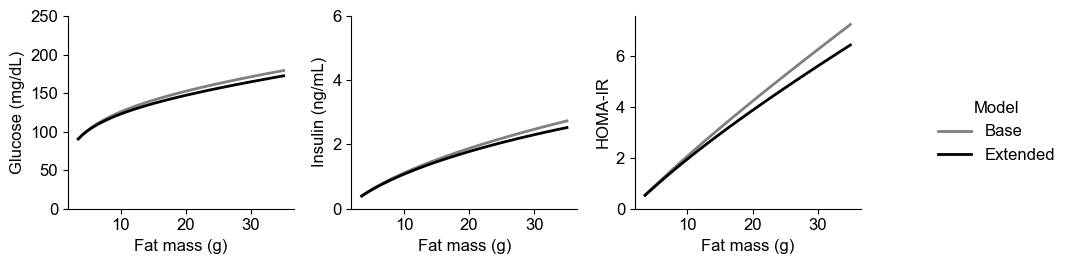

In [5]:
# Prepare data for plotting using FacetGrid (matching type_I_diabetes style)
fat_mass = A_range * 3.5

# Create dataframes for each metric
df_glucose = pd.DataFrame({
    'fat_mass': np.concatenate([fat_mass, fat_mass]),
    'value': np.concatenate([G_base * 90, G_ext * 90]),
    'model': ['Base']*len(fat_mass) + ['Extended']*len(fat_mass),
    'variable': 'Glucose'
})

df_insulin = pd.DataFrame({
    'fat_mass': np.concatenate([fat_mass, fat_mass]),
    'value': np.concatenate([I_base/I0_base * 0.4, I_ext/I0_ext * 0.4]),
    'model': ['Base']*len(fat_mass) + ['Extended']*len(fat_mass),
    'variable': 'Insulin'
})

df_homa = pd.DataFrame({
    'fat_mass': np.concatenate([fat_mass, fat_mass]),
    'value': np.concatenate([HOMA_IR_base, HOMA_IR_ext]),
    'model': ['Base']*len(fat_mass) + ['Extended']*len(fat_mass),
    'variable': 'HOMA-IR'
})

# Combine all data
plot_data_steady = pd.concat([df_glucose, df_insulin, df_homa], axis=0, ignore_index=True)

# Create FacetGrid plot
g = sns.FacetGrid(plot_data_steady, col="variable", col_wrap=3, height=2.8, aspect=0.9,
                  col_order=['Glucose', 'Insulin', 'HOMA-IR'], sharey=False, sharex=True, hue='model',
                  hue_order=['Base', 'Extended'],
                  palette={'Extended': 'black', 'Base': 'grey'})

g.map_dataframe(sns.lineplot, x="fat_mass", y="value", linewidth=2)

# Set y-axis labels with units
g.axes[0].set_ylabel("Glucose (mg/dL)")
g.axes[1].set_ylabel("Insulin (ng/mL)")
g.axes[2].set_ylabel("HOMA-IR")

# Set x-axis labels
for i in range(3):
    g.axes[i].set_xlabel("Fat mass (g)")

# Set y-axis limits
g.axes[0].set_ylim(0, 250)
g.axes[1].set_ylim(0, 6)
g.axes[2].set_ylim(0, None)  # Auto-scale HOMA-IR

g.set_titles("")
g.add_legend(title='Model', bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.tight_layout()
sns.despine()
plt.savefig('./output/obesity_steady_state_comparison.svg', bbox_inches='tight')
plt.show()

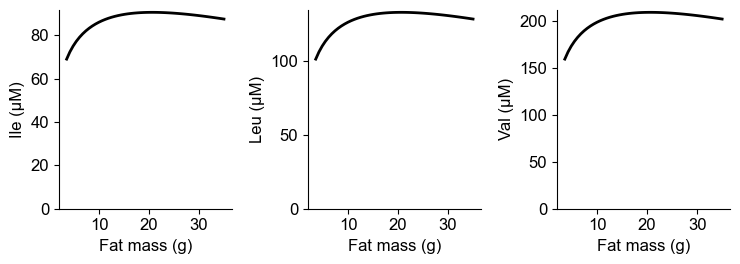

In [6]:
# Plot BCAAs separately in 3 panels
# BCAA reference concentrations from serum data (µM)
BCAA_ref = {'Ile': 67.0, 'Leu': 98.2, 'Val': 155.0}
BCAA_names = ['Ile', 'Leu', 'Val']
BCAA_indices = [AMINO_ACIDS.index(aa) for aa in BCAA_names]

# Extract and scale BCAA concentrations from extended model (states 8+ are amino acids)
# Scale each BCAA by its reference concentration to get µM
BCAA_ext_scaled = np.zeros((len(A_range), 3))
for i, aa in enumerate(BCAA_names):
    aa_idx = 8 + BCAA_indices[i]
    BCAA_ext_scaled[:, i] = results_ext[:, aa_idx] * BCAA_ref[aa]

# Create BCAA dataframes (Extended model only)
df_bcaa_list = []
for i, aa in enumerate(BCAA_names):
    df_aa = pd.DataFrame({
        'fat_mass': fat_mass,
        'value': BCAA_ext_scaled[:, i],
        'model': 'Extended',
        'variable': aa
    })
    df_bcaa_list.append(df_aa)

# Combine BCAA data
plot_data_bcaa = pd.concat(df_bcaa_list, axis=0, ignore_index=True)

# Create FacetGrid plot for BCAAs
g = sns.FacetGrid(plot_data_bcaa, col="variable", col_wrap=3, height=2.8, aspect=0.9,
                  col_order=['Ile', 'Leu', 'Val'], 
                  sharey=False, sharex=True, hue='model',
                  hue_order=['Extended'],
                  palette={'Extended': 'black'}
                )

g.map_dataframe(sns.lineplot, x="fat_mass", y="value", linewidth=2)

# Set y-axis labels with units
g.axes[0].set_ylabel("Ile (µM)")
g.axes[1].set_ylabel("Leu (µM)")
g.axes[2].set_ylabel("Val (µM)")

# Set x-axis labels
for i in range(3):
    g.axes[i].set_xlabel("Fat mass (g)")

# Set y-axis limits to auto-scale
for i in range(3):
    g.axes[i].set_ylim(0, None)

g.set_titles("")
plt.tight_layout()
sns.despine()
plt.savefig('./output/obesity_bcaa_comparison.svg', bbox_inches='tight')
plt.show()

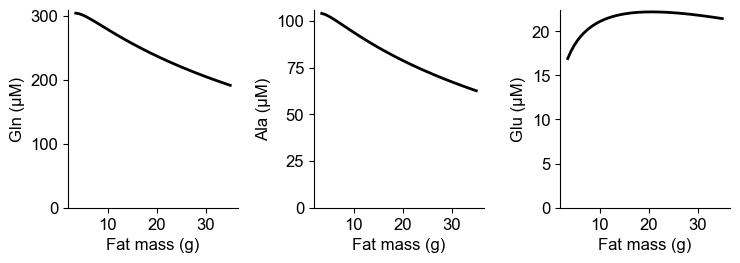

In [7]:
# Plot Glutamine, Alanine, and Glutamate separately in 3 panels
# Reference concentrations from serum data (µM)
AA_ref = {'Gln': 363.0, 'Ala': 202.0, 'Glu': 16.4}
AA_names = ['Gln', 'Ala', 'Glu']
AA_indices = [AMINO_ACIDS.index(aa) for aa in AA_names]

# Extract and scale amino acid concentrations from extended model (states 8+ are amino acids)
# Scale each AA by its reference concentration to get µM
AA_ext_scaled = np.zeros((len(A_range), 3))
for i, aa in enumerate(AA_names):
    aa_idx = 8 + AA_indices[i]
    AA_ext_scaled[:, i] = results_ext[:, aa_idx] * AA_ref[aa]

# Create amino acid dataframes (Extended model only)
df_aa_list = []
for i, aa in enumerate(AA_names):
    df_aa = pd.DataFrame({
        'fat_mass': fat_mass,
        'value': AA_ext_scaled[:, i],
        'model': 'Extended',
        'variable': aa
    })
    df_aa_list.append(df_aa)

# Combine amino acid data
plot_data_aa = pd.concat(df_aa_list, axis=0, ignore_index=True)

# Create FacetGrid plot for amino acids
g = sns.FacetGrid(plot_data_aa, col="variable", col_wrap=3, height=2.8, aspect=0.9,
                  col_order=['Gln', 'Ala', 'Glu'], 
                  sharey=False, sharex=True, hue='model',
                  hue_order=['Extended'],
                  palette={'Extended': 'black'})

g.map_dataframe(sns.lineplot, x="fat_mass", y="value", linewidth=2)

# Set y-axis labels with units
g.axes[0].set_ylabel("Gln (µM)")
g.axes[1].set_ylabel("Ala (µM)")
g.axes[2].set_ylabel("Glu (µM)")

# Set x-axis labels
for i in range(3):
    g.axes[i].set_xlabel("Fat mass (g)")

# Set y-axis limits to auto-scale
for i in range(3):
    g.axes[i].set_ylim(0, None)

g.set_titles("")
plt.tight_layout()
sns.despine()
plt.savefig('./output/obesity_amino_acids_comparison.svg', bbox_inches='tight')
plt.show()

## Transient Dynamics: Response to Adiposity Increase

Simulate the time course when adiposity increases from 1x to 2x at t=10 min.

We track:
1. Core metabolic variables: Glucose, Insulin, Fatty acids, Lactate
2. Metabolic fluxes: Lipolysis, FA oxidation, Glucose disposal

In [8]:
# Base model dynamics
print("Simulating base model dynamics...")

# Phase 1: Steady state at A=1
time1 = np.linspace(0, 10, 100)
X1_base, F1_base = perturbation_dynamics_base(time1, A=1, p=p_base)

# Phase 2: Increase to A=2
time2 = np.linspace(10.01, 150, 200)
vars_base = ['L', 'G', 'F', 'K', 'I', 'IA']
X0_phase2 = X1_base.loc[X1_base['time'] == 10, vars_base].values[0]
X2_base, F2_base = perturbation_dynamics_base(time2, A=2, p=p_base, X0=X0_phase2)

# Concatenate results
X_base = pd.concat([X1_base, X2_base], axis=0, ignore_index=True)
F_base = pd.concat([F1_base, F2_base], axis=0, ignore_index=True)

# Scale base model outputs
X_base['G_scaled'] = X_base['G'] * 90  # mg/dL
X_base['I_scaled'] = X_base['I'] / I0_base * 0.4  # ng/mL
X_base['L_scaled'] = X_base['L'] * 0.75  # mM
X_base['F_scaled'] = X_base['F'] * 0.5  # mM
X_base['K_scaled'] = X_base['K'] * 0.5  # mM

F_base_scaled = F_base.copy()
# Scale fluxes by vATP
for col in ['vA', 'vF', 'vG', 'vGL']:
    if col in F_base.columns:
        F_base_scaled[col] = F_base[col] * vATP_base
F_base_scaled['vGD'] = (F_base['vG'] + F_base['vGL']) * vATP_base
# Add lipolysis alias for compatibility
F_base_scaled['vLip'] = F_base_scaled['vA']

print("✓ Base model dynamics complete")

Simulating base model dynamics...
✓ Base model dynamics complete


In [9]:
# Extended model dynamics
print("Simulating extended model dynamics...")

# Phase 1: Steady state at A=1
time1 = np.linspace(0, 10, 100)
X1_ext, F1_ext = perturbation_dynamics_ext(time1, A_ref=1, p=p_ext)

# Phase 2: Increase to A=2
time2 = np.linspace(10.01, 150, 200)
state_names_ext = ['L', 'G', 'F', 'K', 'I', 'IA', 'GCG', 'GCGA'] + AMINO_ACIDS
X0_phase2 = X1_ext.loc[X1_ext['time'] == 10, state_names_ext].values[0]
X2_ext, F2_ext = perturbation_dynamics_ext(time2, x0=X0_phase2, A_ref=2, p=p_ext)

# Concatenate results
X_ext = pd.concat([X1_ext, X2_ext], axis=0, ignore_index=True)
F_ext = pd.concat([F1_ext, F2_ext], axis=0, ignore_index=True)

# Scale extended model outputs
X_ext['G_scaled'] = X_ext['G'] * 90  # mg/dL
X_ext['I_scaled'] = X_ext['I'] / I0_ext * 0.4  # ng/mL
X_ext['L_scaled'] = X_ext['L'] * 0.75  # mM
X_ext['F_scaled'] = X_ext['F'] * 0.5  # mM
X_ext['K_scaled'] = X_ext['K'] * 0.5  # mM

F_ext_scaled = F_ext.copy()
# Scale fluxes by vATP
for col in ['vLip', 'vF', 'vG', 'vGL']:
    if col in F_ext.columns:
        F_ext_scaled[col] = F_ext[col] * vATP_ext
F_ext_scaled['vGD'] = (F_ext['vG'] + F_ext['vGL']) * vATP_ext
# Add vA alias for compatibility with base model plotting
F_ext_scaled['vA'] = F_ext_scaled['vLip']

print("✓ Extended model dynamics complete")

Simulating extended model dynamics...
✓ Extended model dynamics complete


## Plot 2: Transient Response Comparison

Compare the dynamic response to adiposity increase (1x → 2x at t=10 min).

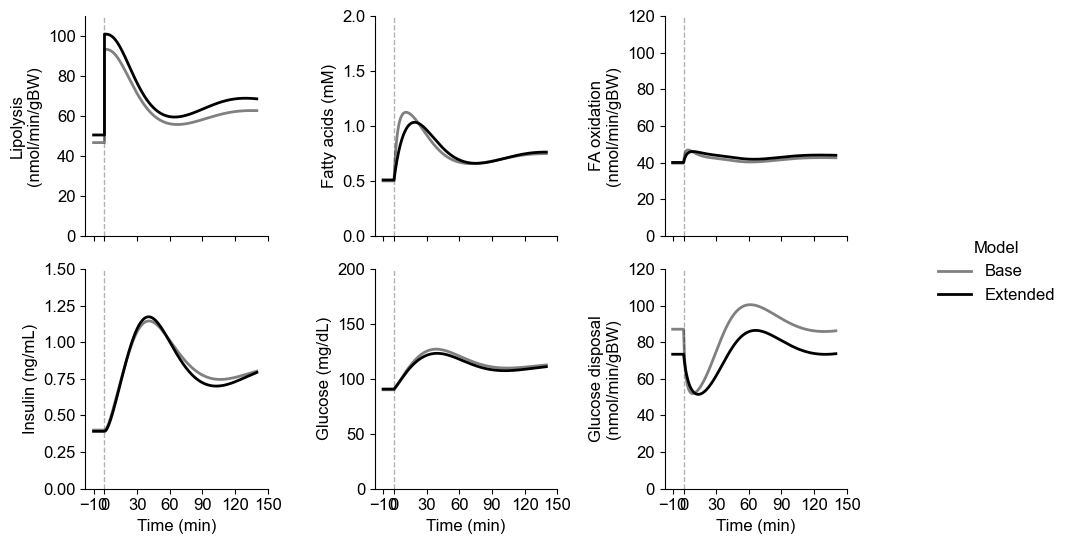

In [10]:
# Prepare data for transient dynamics plotting (matching type_I_diabetes style)
# Shift time so perturbation at t=0
time_shifted_base = X_base['time'] - 10
time_shifted_ext = X_ext['time'] - 10

# Create combined dataframes for each variable
df_glucose_dyn = pd.DataFrame({
    'time': np.concatenate([time_shifted_base, time_shifted_ext]),
    'value': np.concatenate([X_base['G_scaled'], X_ext['G_scaled']]),
    'model': ['Base']*len(time_shifted_base) + ['Extended']*len(time_shifted_ext),
    'variable': 'G'
})

df_insulin_dyn = pd.DataFrame({
    'time': np.concatenate([time_shifted_base, time_shifted_ext]),
    'value': np.concatenate([X_base['I_scaled'], X_ext['I_scaled']]),
    'model': ['Base']*len(time_shifted_base) + ['Extended']*len(time_shifted_ext),
    'variable': 'I'
})

df_fa_dyn = pd.DataFrame({
    'time': np.concatenate([time_shifted_base, time_shifted_ext]),
    'value': np.concatenate([X_base['F_scaled'], X_ext['F_scaled']]),
    'model': ['Base']*len(time_shifted_base) + ['Extended']*len(time_shifted_ext),
    'variable': 'F'
})

df_lipolysis_dyn = pd.DataFrame({
    'time': np.concatenate([F_base_scaled['time'] - 10, F_ext_scaled['time'] - 10]),
    'value': np.concatenate([F_base_scaled['vA'], F_ext_scaled['vA']]),
    'model': ['Base']*len(F_base_scaled) + ['Extended']*len(F_ext_scaled),
    'variable': 'vLip'
})

df_fa_ox_dyn = pd.DataFrame({
    'time': np.concatenate([F_base_scaled['time'] - 10, F_ext_scaled['time'] - 10]),
    'value': np.concatenate([F_base_scaled['vF'], F_ext_scaled['vF']]),
    'model': ['Base']*len(F_base_scaled) + ['Extended']*len(F_ext_scaled),
    'variable': 'vF'
})

df_gd_dyn = pd.DataFrame({
    'time': np.concatenate([F_base_scaled['time'] - 10, F_ext_scaled['time'] - 10]),
    'value': np.concatenate([F_base_scaled['vGD'], F_ext_scaled['vGD']]),
    'model': ['Base']*len(F_base_scaled) + ['Extended']*len(F_ext_scaled),
    'variable': 'vGD'
})

# Combine all dynamics data
plot_data_dynamics = pd.concat([df_glucose_dyn, df_insulin_dyn, df_fa_dyn, 
                                 df_lipolysis_dyn, df_fa_ox_dyn, df_gd_dyn], 
                                axis=0, ignore_index=True)

# Create FacetGrid plot (2 rows x 3 columns)
g = sns.FacetGrid(plot_data_dynamics, col="variable", col_wrap=3, height=2.8, aspect=0.9,
                  col_order=['vLip', 'F', 'vF', 'I', 'G', 'vGD'], 
                  sharey=False, sharex=True, hue='model',
                  hue_order=['Base', 'Extended'],
                  palette={'Extended': 'black', 'Base': 'grey'})

g.map_dataframe(sns.lineplot, x="time", y="value", linewidth=2)

# Add vertical line at perturbation time (t=0)
for ax in g.axes:
    ax.axvline(0, color='black', linestyle='--', alpha=0.3, linewidth=1)

# Shift x-axis ticks to show time relative to perturbation
for ax in g.axes:
    ax.set_xticks([-10, 0, 30, 60, 90, 120, 150])

# Set y-axis labels with proper units
g.axes[0].set_ylabel("Lipolysis\n(nmol/min/gBW)")
g.axes[1].set_ylabel("Fatty acids (mM)")
g.axes[2].set_ylabel("FA oxidation\n(nmol/min/gBW)")
g.axes[3].set_ylabel("Insulin (ng/mL)")
g.axes[4].set_ylabel("Glucose (mg/dL)")
g.axes[5].set_ylabel("Glucose disposal\n(nmol/min/gBW)")

# Set x-axis labels
for i in range(6):
    g.axes[i].set_xlabel("Time (min)")

# Set y-axis limits
g.axes[0].set_ylim(0, 110)   # Lipolysis
g.axes[1].set_ylim(0, 2.0)   # FA
g.axes[2].set_ylim(0, 120)   # FA oxidation
g.axes[3].set_ylim(0, 1.5)   # Insulin
g.axes[4].set_ylim(0, 200)   # Glucose
g.axes[5].set_ylim(0, 120)   # Glucose disposal

g.set_titles("")
g.add_legend(title='Model', bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.tight_layout()
sns.despine()
plt.savefig('./output/obesity_dynamics_comparison.svg', bbox_inches='tight')
plt.show()